# Week 8 - session material 

##  Loading images, differences between images and 2D lists of lists

Images are very similar to lists of lists, but not all functions that work on numpy images work on lists of lists. 

1) Set up a 10x10 list of lists which is a checkerboard where alternating pixels are black and white. Display the image. Print out the minimum and maximum values in the image.

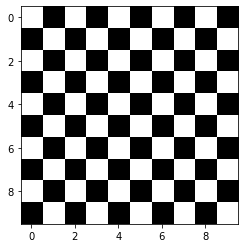

1
0


In [3]:
import numpy as np
import matplotlib.pyplot as plt

#Start with an image filled with zeros. Remember * for a list makes
#copies.
size=10

image=[]
for row in range(0,size):
    image.append([])
    for column in range(0,size):
        image[row].append(0)

# Draw a circular shape centred on the middle of the image
for row in range(0,size):
    for column in range(0,size):
        if (row + column)%2 ==0:
            image[column][row] = 1

plt.imshow(image, cmap="gray")
plt.show()

potentialmaxes = []

for row in range(0,size):
    potentialmaxes.append(max(image[row]))
    
print(max(potentialmaxes))

potentialmins = []

for row in range(0,size):
    potentialmins.append(min(image[row]))
    
print(min(potentialmins))

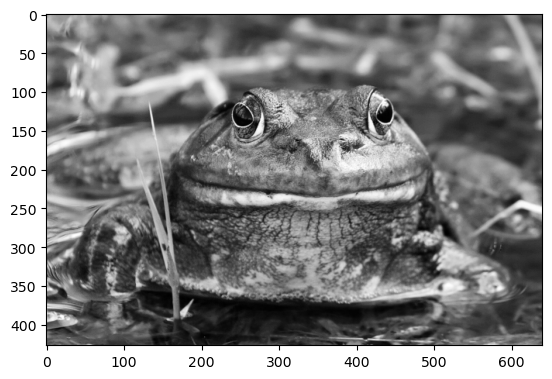

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#open and read in file and show it
bullfrog = plt.imread('image_processing_data/bullfrog.png')

plt.imshow(bullfrog, cmap="gray")
plt.show()

### Simple image manipulation

For the file `bullfrog.png`, write an algorithm which creates a new image whose values are zero when the corresponding pixel in bullfrog.png is less than half the maximum value in the image, and is equal to the corresponding pixel in bullfrog.png otherwise.

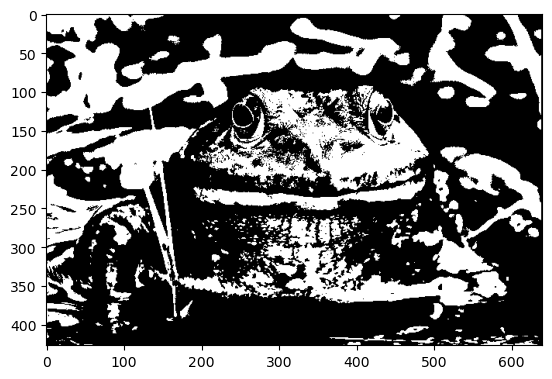

In [4]:
maxfrog = bullfrog.max()

rows = len(bullfrog)
columns = len(bullfrog[0])
thresholded = np.zeros((rows,columns))
    
for row in range(rows):
    for column in range(columns-1):
        if bullfrog[row][column] > maxfrog/2:
            thresholded[row][column]=1
        else:
            thresholded[row][column]=0

plt.imshow(thresholded,cmap="gray")
plt.show()

## Pearson's correlation coefficient

Pearson's correlation coefficient is a measure for how correlated two images are. It ranges from one for completely correlated images (that is, those which are identical) to -1 for images which are anticorrelated (that is, one image is exactly the opposite of the other). Search for information about Pearson's correlation coefficient and summarise your findings below.

The equation for Pearson's correlation coefficient is:

$$
\bar{x} = \frac{1}{N} \sum_{i=1}^N x_i
$$
the correlation coefficient as:
$$
r = \frac{\sum_{i=1}^N (x_i - \bar{x})(y_i - \bar{y})}{
\sqrt{\sum_{i=1}^N (x_i - \bar{x})^2}
\sqrt{\sum_{i=1}^N (y_i - \bar{y})^2}
}
$$

Write a program to calculate the coefficient for a pair of images. Use the test images bullfrog.png and bullfrog_invert.png to test it. If you give this algorithm a pair of identical images, then the answer should be 1, and if you give it a pair of images where one is inverted relative to the other, then the answer should be -1.

(1040, 1040)


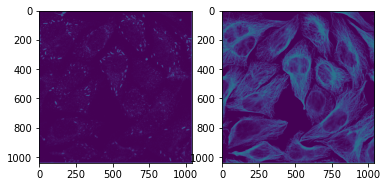

0.01523399665358071 0.09899117061994284
0.4100874209595487


In [10]:
import matplotlib.pyplot as plt
import numpy as np

#Here I'm going to calculate pearsons correlation coefficient for two different colours

image1 = plt.imread('image_processing_data/pearsons_correlation/STK3/STK3.png').astype(np.float64)
image2 = plt.imread('image_processing_data/pearsons_correlation/STK3/microtubules.png').astype(np.float64)

sizeimage = image1.shape
print(sizeimage)

plt.subplot(1,2,1)
plt.imshow(image1)
plt.subplot(1,2,2)
plt.imshow(image2)
plt.show()


newimage1 = np.zeros(sizeimage)

mean1 = 0
mean2 = 0
#calculate means
for i in range(sizeimage[0]):
    for j in range(sizeimage[1]):
        mean1 += image1[i][j];
        mean2 += image2[i][j];

mean1 = mean1/(sizeimage[0]*sizeimage[1])
mean2 = mean2/(sizeimage[0]*sizeimage[1])

print(mean1,mean2)

PCCcoeff1 = 0
PCCcoeff2 = 0
PCCcoeff3 = 0
#calculate the components of the PCC
for i in range(sizeimage[0]):
    for j in range(sizeimage[1]):
        PCCcoeff1 += (image1[i][j] - mean1)*(image2[i][j] - mean2)  
        PCCcoeff2 += (image1[i][j] - mean1)**2
        PCCcoeff3 += (image2[i][j] - mean2)**2

#calculate PCC
PCC = PCCcoeff1/((PCCcoeff2**0.5)*(PCCcoeff3**0.5))
print(PCC)



## Localisation of SRRM and STK3 proteins

Two sets of images have been supplied. Both are taken in U2OS cells. One is for the protein SRRM, and one is for the protein STK3. Each image set shows the localisation of the protein, and of a number of other cell structures. Use Pearson's correlation coefficient to investigate which cell structures each of these proteins is correlated with.

Examine the images by eye. Do your observations lead you to the same conclusion as your calculations?

The disadvantage of Pearson's correlation coefficient is that it calculates for an entire image. For some proteins, it does not make sense to ask how correlated the entire image is, since the protein only takes up a very small region of the image. In these cases it makes more sense to ask whether, if there is a particular protein present in the image, presence of other cell structures is correlated.

Modify your algorithm to calculate Pearson's correlation coefficient only for those regions where the SRRM or STK3 protein intensity rises above a threshold (which you will need to select). How do your results change?

(1040, 1040)


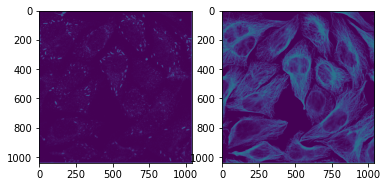

0.6007562993078555 0.6223618166397658
0.7983071957633417


In [24]:
import matplotlib.pyplot as plt
import numpy as np

#Here Im going to calculate pearsons correlation coefficient for two different colour

image1 = plt.imread('image_processing_data/pearsons_correlation/STK3/STK3.png').astype(np.float64)
image2 = plt.imread('image_processing_data/pearsons_correlation/STK3/microtubules.png').astype(np.float64)

sizeimage = image1.shape
print(sizeimage)

plt.subplot(1,2,1)
plt.imshow(image1)
plt.subplot(1,2,2)
plt.imshow(image2)
plt.show()

#this is where I'm doing the thresholding to select only those pixels in the STK image that have above a certain level of intensity
image1thresh = np.zeros(sizeimage)
numthreshedvalues = 0
threshvalue1 = image1.max()/2
for i in range(sizeimage[0]):
    for j in range(sizeimage[1]):
        if image1[i][j] > threshvalue1:
            image1thresh[i][j] = 1 
            numthreshedvalues+=1


newimage1 = np.zeros(sizeimage)

mean1 = 0
mean2 = 0
#calculate means
for i in range(sizeimage[0]):
    for j in range(sizeimage[1]):
        mean1 += image1[i][j]*image1thresh[i][j];
        mean2 += image2[i][j]*image1thresh[i][j];

mean1 = mean1/numthreshedvalues
mean2 = mean2/numthreshedvalues

print(mean1,mean2)

PCCcoeff1 = 0
PCCcoeff2 = 0
PCCcoeff3 = 0
#calculate the components of the PCC
for i in range(sizeimage[0]):
    for j in range(sizeimage[1]):
        PCCcoeff1 += image1thresh[i][j]*(image1[i][j] - mean1)*(image2[i][j] - mean2)  
        PCCcoeff2 += image1thresh[i][j]*(image1[i][j] - mean1)**2
        PCCcoeff3 += image1thresh[i][j]*(image2[i][j] - mean2)**2

#calculate PCC
PCC = PCCcoeff1/((PCCcoeff2**0.5)*(PCCcoeff3**0.5))
print(PCC)
